In [1]:
from matplotlib import animation
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import HTML
#from vpython import sphere, vector, rate, color, scene, curve

plt.rcParams['animation.embed_limit'] = 2**128

%matplotlib inline

class Mass(object):
    """
    Class storing information about a mass, including position, and velocity. 

    Data Attributes:
        mass
        position
        velocity
   
    """
    def __init__(self, mass, position, velocity):
        self.mass = mass
        self.position = np.array(position)
        self.velocity = np.array(velocity)

class System():
    def __init__(self, Masses: list[Mass], Natural_units = True, epsilon=0.01):
        self.N = len(Masses)
        self.sys = Masses
        self.epsilon = epsilon

        self.masses = np.array([m.mass for m in Masses])
        self.positions = np.array([m.position for m in Masses])
        self.velocities = np.array([m.velocity for m in Masses])

        if Natural_units:
            self.G = 4 * np.pi * np.pi
        else:
            self.G = 6.67430e-11

        self.trajectory = None

    def acc(self, X, t):
        """This function calculates acceleration using Newtons law of gravitation, given the positions, X of N masses"""

        atot = np.zeros((self.N,3))

        for i in range(self.N):

            for j in range(self.N):
                if j == i:
                    continue

                r_vec = X[j] - X[i] #Calculate displacement between mass i and j
                r = np.linalg.norm(r_vec)

                if r > 0: #epsilon should stop this from breaking (may be redundant)

                    #acceleration of mass i due to mass j
                    a_ij = self.G * self.masses[j] * r_vec / (r**2 + self.epsilon**2)**(3/2)

                    atot[i] += a_ij

        return atot
    
    def acc_2(self, X, t):
        """This function calculates acceleration using Newtons law of gravitation, given the positions, X of N masses"""
        #Does vectorized operations, should be faster for larger N, but slower for small N due to overhead of vectorization
        
        X_i = X[:, np.newaxis, :]  # (N, 1, 3)
        X_j = X[np.newaxis, :, :]  # (1, N, 3)
        r_vec = X_j - X_i  # (N, N, 3)

        r = np.linalg.norm(r_vec, axis=2)  # (N, N)
        r = np.where(r == 0, np.inf, r)
        acc_matrix = self.G * self.masses[np.newaxis, :, np.newaxis] * r_vec / (r[:, :, np.newaxis]**2 + self.epsilon**2)**(3/2)
        atot = np.sum(acc_matrix, axis=1)  #shape (N, 3)

        return atot
    
    def rk4(self, t, acc_func = None):
        """This function"""
        dt = t[1] - t[0]   

        if acc_func is None:
            #Currently have 2 acceleration functions. Can choose or defaults to acc_2
            #may remove later if we go with only one acc function
            acc_func = self.acc_2

        x = self.positions
        v = self.velocities

        k1v  = dt * acc_func(x, t[0])
        k1x = dt * v

        k2v = dt * acc_func(x + k1x/2, t[0] + dt/2)
        k2x = dt * (v + k1v/2) 

        k3v = dt * acc_func(x + k2x/2, t[0] + dt/2)
        k3x = dt * (v + k2v/2)

        k4v = dt * acc_func(x + k3x, t[0] + dt)
        k4x = dt * (v + k3v)

        #Allocating space for trajectory
        xtraj = np.zeros((len(t), self.N, 3))
        vtraj = np.zeros((len(t), self.N, 3))
        
        #Setting initial position and velocity
        xtraj[0] = x
        vtraj[0] = v

        for i in range(1, len(t)):
            term2x = 1/6 * (k1x + 2*k2x + 2*k3x + k4x)
            term2v = 1/6 * (k1v + 2*k2v + 2*k3v + k4v)

            x = x + term2x
            v = v + term2v
            
            k1v  = dt * acc_func(x, t[i])
            k1x = dt * v

            k2v = dt * acc_func(x + k1x/2, t[i] + dt/2)
            k2x = dt * (v + k1v/2) 

            k3v = dt * acc_func(x + k2x/2, t[i] + dt/2)
            k3x = dt * (v + k2v/2)

            k4v = dt * acc_func(x + k3x, t[i] + dt)
            k4x = dt * (v + k3v)

            xtraj[i] = x
            vtraj[i] = v

        #Combine into a single array of shape (len(t), N, 6)
        ptraj = np.concatenate((xtraj, vtraj), axis = 2)
        self.trajectory = ptraj

        return ptraj
    
    def leapfrog(self, t, acc_func = None):
        """This function"""
        dt = t[1] - t[0]

        x = self.positions
        v = self.velocities 

        if acc_func is None:
            #Currently have 2 acceleration functions, can choose, or defaults to acc_2
            #may remove later if we go with only one acc function
            acc_func = self.acc_2

        a = acc_func(x, t[0])

        #first half step for velocity, using acceleration at initial positions
        v_half = v + a * dt / 2

        #Allocating space for trajectory
        xtraj = np.zeros((len(t), self.N, 3))
        vtraj = np.zeros((len(t), self.N, 3))

        #Setting initial position and velocity (initial v_half)
        xtraj[0] = x
        vtraj[0] = v_half

        for i in range(1, len(t)):

            x = x + v_half * dt

            a = acc_func(x, t)
        
            v_half = v_half + a * dt

            xtraj[i] = x
            vtraj[i] = v_half

        #Combine into a single array of shape (len(t), N, 6)
        ptraj = np.concatenate((xtraj, vtraj), axis = 2)

        self.trajectory = ptraj

        return ptraj
    
    def plot(self, elev = 90, azim = -90):

        if self.trajectory is None:
            #may just run one of them automatically later, instead of raising an error
            raise ValueError("No trajectory found. Run rk4 or leapfrog to generate trajectory before plotting.")
        
        fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
        ax.set_xlabel('X(AU)')
        ax.set_ylabel('Y(AU)')
        ax.set_zlabel('Z(AU)')
        ax.view_init(elev=elev, azim=azim)

        positions = self.trajectory[:,:,:3]

        for i in range(self.N):
            ax.plot(positions[:,i,0], positions[:,i,1], positions[:,i,2])
        plt.show()

    def phase_plot(self):
        """This function"""

        #May not be needed, since phase space volume is across all dimensions
        #better checked using Ei/Ef

        if self.trajectory is None:
            #may just run one of them automatically later, instead of raising an error
            raise ValueError("No trajectory found. Run rk4 or leapfrog to generate trajectory before plotting.")

        positions = self.trajectory[:,:,:3]
        velocities = self.trajectory[:,:,3:]
    
        fig, ax = plt.subplots(1,3, figsize=(15,5))

        for body in range(self.N):
            ax[0].plot(positions[:,body,0], velocities[:,body,0])
            ax[1].plot(positions[:,body,1], velocities[:,body,1])
            ax[2].plot(positions[:,body,2], velocities[:,body,2])

        ax[0].set_title('Phase plot - X vs Vx')
        ax[1].set_title('Phase plot - Y vs Vy')
        ax[2].set_title('Phase plot - Z vs Vz')

        ax[0].set_xlabel('X (AU)')
        ax[0].set_ylabel('Vx (AU/yr)')
        ax[1].set_xlabel('Y (AU)')
        ax[1].set_ylabel('Vy (AU/yr)')
        ax[2].set_xlabel('Z (AU)')
        ax[2].set_ylabel('Vz (AU/yr)')
        plt.show()

    def _init_animate(self):
        """This function"""
        for line, pt in zip(self.lines, self.pts):
            line.set_data([], [])
            line.set_3d_properties([])

            pt.set_data([], [])
            pt.set_3d_properties([])

        return self.lines + self.pts
    
    def _Animate(self, itr):

        #shape (tmax, N, 3)
        positions = self.trajectory[:,:,:3]

        #shape (N, tmax, 3)
        positions = positions.transpose(1, 0, 2)

        for line, pt, pi in zip(self.lines, self.pts, positions):
            
            #Not sure if I need to transpose?
            line.set_data(pi[:itr,0].T, pi[:itr,1].T)
            line.set_3d_properties(pi[:itr,2].T)

            pt.set_data([pi[itr,0].T], [pi[itr,1].T])
            pt.set_3d_properties([pi[itr,2].T])

            #line.set_data(pi[:itr,0], pi[:itr,1])
            #line.set_3d_properties(pi[:itr,2])

            #pt.set_data([pi[itr,0]], [pi[itr,1]])
            #pt.set_3d_properties([pi[itr,2]])

        return self.lines + self.pts
    
    def Simulate(self, title = 'N-body Simulation'):
        """Animates using Matplotlib"""

        if self.trajectory is None:
            #may just run one of them automatically later, instead of raising an error
            raise ValueError("No trajectory found. Run rk4 or leapfrog to generate trajectory before simulating.")

        fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
        ax.set_title(f"{title}")
        ax.set_xlabel('X(AU)')
        ax.set_ylabel('Y(AU)')
        ax.set_zlabel('Z(AU)')
        ax.set_xlim(np.min(self.trajectory[:,:,0]), np.max(self.trajectory[:,:,0]))
        ax.set_ylim(np.min(self.trajectory[:,:,1]), np.max(self.trajectory[:,:,1]))


        
        #This doesn't like when the system is stuck in a plane
        ax.set_zlim(np.min(self.trajectory[:,:,2]), np.max(self.trajectory[:,:,2]))


        colors = plt.cm.jet(np.linspace(0, 1, self.N))

        self.lines = sum([ax.plot([], [], [], '-', c=c)
             for c in colors], [])
        
        self.pts = sum([ax.plot([], [], [], 'o', c=c)
           for c in colors], [])

        anim = animation.FuncAnimation(fig, self._Animate, init_func = self._init_animate, frames=len(self.trajectory), interval=50, blit = True)
        HTML(anim.to_jshtml())
        
        

    # def Simulate2(self, title = "N-body Simulation"):
    #     """Animates using vpython"""

    #     if self.trajectory is None:
    #         #may just run one of them automatically later, instead of raising an error
    #         raise ValueError("No trajectory found. Run rk4 or leapfrog to generate trajectory before simulating.")
        
    #     scene.title = title
    #     scene.width = 800
    #     scene.height = 600
    #     scene.background = color.black

    #     positions = self.trajectory[:,:,:3]

    #     # Colors for bodies
    #     colors_list = []
    #     for i in range(self.N):
    #         rgb = np.random.rand(3)
    #         colors_list.append(vector(*rgb))

    #     # Create spheres and trails for each body
    #     bodies = []
    #     for i in range(self.N):
    #         b = sphere(pos=vector(*positions[0,i]), radius=0.2, color=colors_list[i%len(colors_list)])
    #         b.trail = curve(color=colors_list[i%len(colors_list)], radius=0.05)
    #         bodies.append(b)

    #     # Animate
    #     for t_idx in range(len(positions)):
    #         rate(60)  # fps
    #         for i in range(self.N):
    #             # Update position
    #             bodies[i].pos = vector(*positions[t_idx,i])
    #             # Update trail
    #             bodies[i].trail.append(bodies[i].pos)


#Units of AU, Solar Masses and Years
#Keplers law leads to G = 4 * pi * pi



#sun = Mass(1.989*10**30, np.zeros(3), np.zeros(3))
#earth = Mass(5.97*10**24, np.array([1.496*10**11,0,0]), np.array([0,29800,0]))




#test timing of acc and acc_2
#   - acc uses nested for loops
#   - acc_2 uses entirely vectorized np math (thus operations are done in more optimized C)
#   - acc_2 should be faster at larger N
#   - both are still O(n^2)
 
# ts = time.time()
# ptraj = es.rk4(np.linspace(0,1,1000), es.acc)
# te = time.time()
# acct1 = ts-te
# print("Rk4 Time for acc: ", te - ts)

# ts = time.time()
# ptraj2 = es.rk4(np.linspace(0,1,1000), es.acc_2)
# te = time.time()
# acc2t1 = ts-te
# print("Rk4 Time for acc_2: ", te - ts)

# ts = time.time()
# ptraj3 = es.leapfrog(np.linspace(0,10,1000), es.acc)
# te = time.time()
# acct2 = ts-te
# print("Leapfrog Time for acc: ", te - ts)

# ts = time.time()
# ptraj4 = es.leapfrog(np.linspace(0,10,1000), es.acc_2)
# te = time.time()
# acc2t2 = ts-te
# print("Leapfrog Time for acc_2: ", te - ts)

# print(acct2/acct1, acc2t2/acc2t1)


#es.Simulate2()


#1. epsilon is force softener (needs to be checked with collision simulations)

#2. The x and v returned from the leapfrog method do not agree on time
#   - x is at full step, v is at half step
#   - Either leave it, or average out the half step v to get time agreement with x
#   - Also, the initial velocity is left out (vtraj only store v_half)

#3. Need to include other cases
#   - lagrange
#   - collision

#4. Make animation nicer
#   - More inputs to simulate() function

#5. Can exclude t in acc and thus also as an input when calling since t is not used. Really just there from convention/force of habit

#6. Make more dynamic with units
#   - Adjust labels on plot



C:\Users\matth\AppData\Local\Temp\ipykernel_32740\3595557224.py:289: UserWarning: Attempting to set identical low and high zlims makes transformation singular; automatically expanding.
  ax.set_zlim(np.min(self.trajectory[:,:,2]), np.max(self.trajectory[:,:,2]))


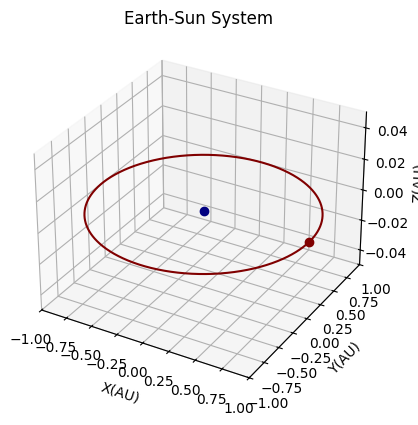

In [23]:
#Sun-Earth System

sun = Mass(1, np.zeros(3), np.zeros(3))
earth = Mass(3.00274e-6, np.array([1,0,0]), np.array([0,2*np.pi,0]))



es = System([sun,earth])
ptraj = es.rk4(np.linspace(0, 1, 1000))
es.Simulate('Earth-Sun System')

C:\Users\matth\AppData\Local\Temp\ipykernel_32740\3595557224.py:289: UserWarning: Attempting to set identical low and high zlims makes transformation singular; automatically expanding.
  ax.set_zlim(np.min(self.trajectory[:,:,2]), np.max(self.trajectory[:,:,2]))


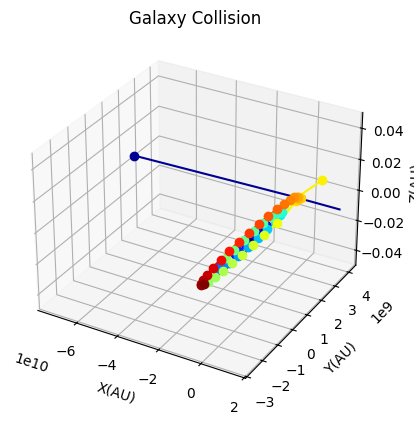

In [34]:
#Galaxy Collision

def pctoau(pc):
    return pc*206265

def period(a, M):   ######IN NATURAL UNITS
    return a**(3/2)/M**(1/2)

def creategalaxysystem(b, innerringstars = 10, perturberspeed = 0.0):
    system = []
    mainmass = 10**11
    perturmass = 10**10
    main = Mass(mainmass, np.zeros(3), np.zeros(3))
    perturber = Mass(perturmass, np.array([pctoau(100000), b, 0.0]), np.array([-perturberspeed, 0.0, 0.0]))
    
    system.append(main)
    system.append(perturber)

    innerring = np.linspace(0, 2*np.pi*(innerringstars-1)/innerringstars, innerringstars)
    midring = np.linspace(0, 2*np.pi*(2*innerringstars-1)/2/innerringstars, 2*innerringstars)
    outerring = np.linspace(0, 2*np.pi*(3*innerringstars-1)/3/innerringstars, 3*innerringstars)

    ri = pctoau(5000)
    rm = pctoau(10000)
    ro = pctoau(15000)

    ip = period(ri, mainmass)  #Inner ring period
    mp = period(rm, mainmass) #Mid ring period
    op = period(ro, mainmass) #Outer ring period

    vi = 2*np.pi*ri/ip            #Inner ring speed
    vm = 2*np.pi*rm/mp            #Mid ring speed
    vo = 2*np.pi*ro/op            #Outer ring speed

    
    for i in innerring:
        ringstar = Mass(0, np.array([ri*np.cos(i), ri*np.sin(i), 0]), np.array([vi*np.sin(i), -vi*np.cos(i), 0]))
        system.append(ringstar)

    for i in midring:
        ringstar = Mass(0, np.array([rm*np.cos(i), rm*np.sin(i), 0]), np.array([vm*np.sin(i), -vm*np.cos(i), 0]))
        system.append(ringstar)

    for i in outerring:
        ringstar = Mass(0, np.array([ro*np.cos(i), ro*np.sin(i), 0]), np.array([vo*np.sin(i), -vo*np.cos(i), 0]))
        system.append(ringstar)

    return System(system)

galsys = creategalaxysystem(pctoau(15000), perturberspeed= 10**3)
galtraj = galsys.rk4(np.linspace(0, 10**8, 1000))
galsys.Simulate('Galaxy Collision')

C:\Users\matth\AppData\Local\Temp\ipykernel_32740\3595557224.py:289: UserWarning: Attempting to set identical low and high zlims makes transformation singular; automatically expanding.
  ax.set_zlim(np.min(self.trajectory[:,:,2]), np.max(self.trajectory[:,:,2]))
C:\Users\matth\AppData\Local\Temp\ipykernel_32740\3595557224.py:289: UserWarning: Attempting to set identical low and high zlims makes transformation singular; automatically expanding.
  ax.set_zlim(np.min(self.trajectory[:,:,2]), np.max(self.trajectory[:,:,2]))


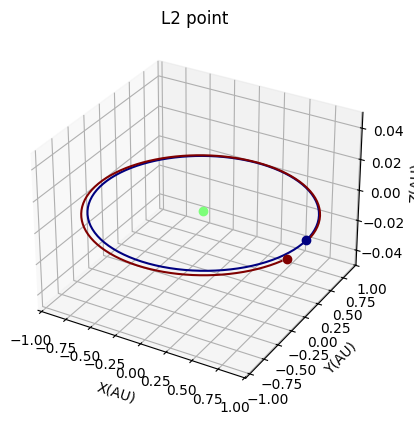

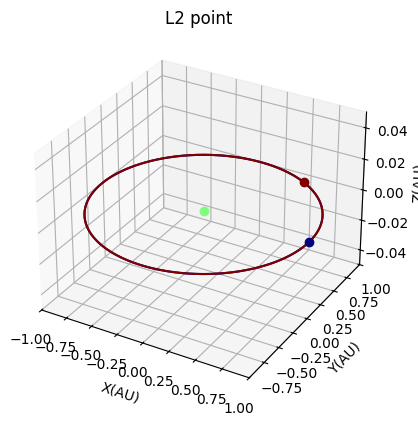

In [ ]:
# Lagrange Points
L2 = Mass(0, np.array([1.01,0,0]), np.array([0,2*np.pi*1.01/period(1.01, 1+3.00274e-6),0]))

L2sys = System([earth, sun, L2])
L2traj = L2sys.rk4(np.linspace(0, 1, 100))
L2sys.Simulate('L2 point')

L4 = Mass(0, np.array([np.cos(np.pi/3),np.sin(np.pi/3),0]), np.array([2*np.pi*np.sin(np.pi/3),-2*np.pi*np.cos(np.pi/3),0]))
L4sys = System([earth, sun, L4])
L4traj = L4sys.rk4(np.linspace(0, 1, 100))
L4sys.Simulate('L4 point')

0.22693261794184083


C:\Users\matth\AppData\Local\Temp\ipykernel_32740\3595557224.py:289: UserWarning: Attempting to set identical low and high zlims makes transformation singular; automatically expanding.
  ax.set_zlim(np.min(self.trajectory[:,:,2]), np.max(self.trajectory[:,:,2]))


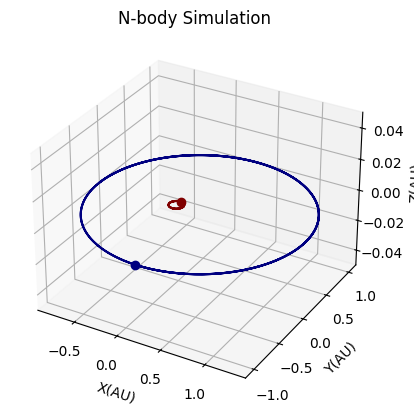

In [47]:
# Three Body

def threebody(M1 = 1.0, M2 = 1.0, M3 = 1.0, separation = 1.0, M3velocity = 10, M3dist = 10, b = 0):
    COM = M2*separation/(M1+M2)    #Origin at M1 (origin will shift to COM later)
    M1dist = -COM
    M2dist = separation-COM
    orbitalperiod = period(abs(M1dist), (M1+M2))
    print(orbitalperiod)
    body1 = Mass(M1, np.array([M1dist, 0.0, 0.0]), np.array([0.0, 2*np.pi*abs(M1dist)/orbitalperiod, 0.0]))   #These initial conditions are at aphelion.
    body2 = Mass(M2, np.array([M2dist, 0.0, 0.0]), np.array([0.0, -2*np.pi*abs(M2dist)/orbitalperiod, 0.0]))
    #body3 = Mass(M3, np.array([M3dist, b, 0.0]), np.array([-M3velocity, 0.0, 0.0]))
    return System([body1, body2])

tb1 = threebody(M1 = 1, M2 = 15, M3 = 0, separation= 1.0, M3velocity= 0.0)
tb1traj = tb1.leapfrog(np.linspace(0, 1, 1000))
tb1.Simulate()
